# **Team 9 - Machine Learning Project**
##Team Member:
- Member 1: PIYUMI HETTIARACHCHIGE DONA (105269437)
- Member 2: Barsa Rana (105203163)
- Member 3: Duc Ha (103492558)
- Member 4: Nishok Periyanaickenpalayam Jothivenkat (105069598)
- Member 5: Tarun Maravanigee Ganesha Prasad (105323346)
- Member 6: Keyur Sandipbhai Patel (105196195)

#Task 2: Machine Learning

##Importing libaries

In [ ]:


import os
import time
import pickle
import tarfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray, rgb2hsv

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Main result folder
RESULTS_DIR = Path("Machine_learning_result")
CACHE_DIR = RESULTS_DIR / "feature_cache"

RESULTS_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Results will be saved in:", RESULTS_DIR)

Results will be saved in: Machine_learning_result



## Load CIFAR-10 dataset


In [ ]:


def load_cifar10_python():
    """
    Loads CIFAR-10 dataset using the official Python version.
    This avoids TensorFlow dependency.
    """

    data_dir = Path("cifar-10-batches-py")
    tar_path = Path("cifar-10-python.tar.gz")

    if not data_dir.exists():
        if not tar_path.exists():
            print("[INFO] Downloading CIFAR-10 dataset...")
            url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
            urllib.request.urlretrieve(url, tar_path)

        print("[INFO] Extracting CIFAR-10 dataset...")
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall()

    def unpickle(file):
        with open(file, "rb") as fo:
            data = pickle.load(fo, encoding="bytes")
        return data

    X_train_list = []
    y_train_list = []

    for i in range(1, 6):
        batch = unpickle(data_dir / f"data_batch_{i}")
        X_train_list.append(batch[b"data"])
        y_train_list.extend(batch[b"labels"])

    X_train_full = np.vstack(X_train_list)
    y_train_full = np.array(y_train_list)

    test_batch = unpickle(data_dir / "test_batch")
    X_test = test_batch[b"data"]
    y_test = np.array(test_batch[b"labels"])

    X_train_full = X_train_full.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return X_train_full, y_train_full, X_test, y_test


X_train_full, y_train_full, X_test, y_test = load_cifar10_python()

print("Full training data:", X_train_full.shape, y_train_full.shape)
print("Test data:", X_test.shape, y_test.shape)

Full training data: (50000, 32, 32, 3) (50000,)
Test data: (10000, 32, 32, 3) (10000,)


## Train-validation-test split

In [ ]:


X_train = X_train_full[:45000]
y_train = y_train_full[:45000]

X_val = X_train_full[45000:50000]
y_val = y_train_full[45000:50000]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (45000, 32, 32, 3) (45000,)
Validation: (5000, 32, 32, 3) (5000,)
Test: (10000, 32, 32, 3) (10000,)


## Display sample images

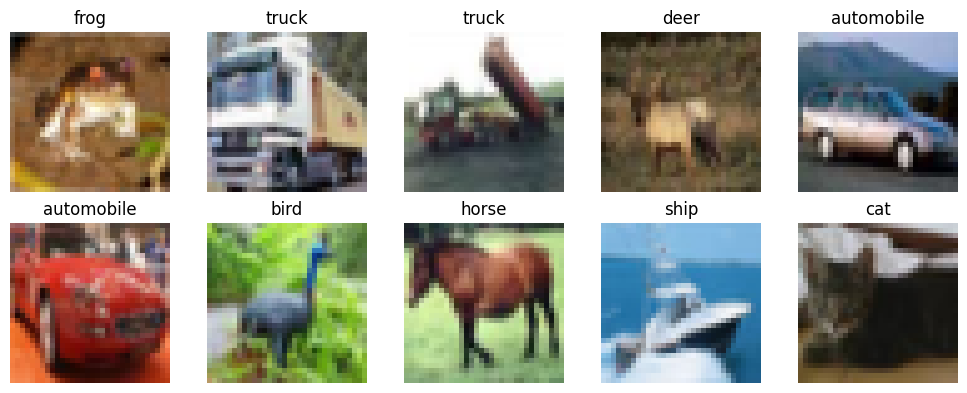

In [ ]:

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(CLASS_NAMES[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_cifar10_images.png", dpi=300)
plt.show()

## Feature extraction

In [ ]:


def extract_hog_features(image):
    """
    HOG captures shape and edge information from the image.
    """
    gray = rgb2gray(image)

    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )


def extract_hsv_color_histogram(image, bins=8):
    """
    HSV histogram captures colour information.
    """
    hsv = rgb2hsv(image)
    features = []

    for channel in range(3):
        hist, _ = np.histogram(
            hsv[:, :, channel],
            bins=bins,
            range=(0, 1),
            density=True
        )
        features.extend(hist)

    return np.array(features)


def extract_lbp_features(image, points=8, radius=1):
    """
    LBP captures local texture patterns.
    """
    gray = rgb2gray(image)

    lbp = local_binary_pattern(
        gray,
        P=points,
        R=radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, points + 3),
        range=(0, points + 2),
        density=True
    )

    return hist


def extract_combined_features(image):
    """
    Combines HOG, HSV colour histogram, and LBP texture features.
    """
    hog_feat = extract_hog_features(image)
    hsv_feat = extract_hsv_color_histogram(image)
    lbp_feat = extract_lbp_features(image)

    return np.concatenate([hog_feat, hsv_feat, lbp_feat])

## Compute image features

In [ ]:


def compute_features(images, split_name, force=False):
    """
    Extracts features and saves them in cache.
    If features already exist, they are loaded to save time.
    """

    cache_file = CACHE_DIR / f"{split_name}_hog_hsv_lbp.npy"

    if cache_file.exists() and not force:
        print(f"[INFO] Loading cached features: {cache_file}")
        return np.load(cache_file)

    print(f"[INFO] Extracting features for {split_name}...")

    features = []

    for image in tqdm(images):
        features.append(extract_combined_features(image))

    features = np.array(features, dtype=np.float32)

    np.save(cache_file, features)

    print(f"[INFO] Saved features: {cache_file}")
    print(f"{split_name} feature shape:", features.shape)

    return features


X_train_feat = compute_features(X_train, "train")
X_val_feat = compute_features(X_val, "validation")
X_test_feat = compute_features(X_test, "test")

print("Train features:", X_train_feat.shape)
print("Validation features:", X_val_feat.shape)
print("Test features:", X_test_feat.shape)

[INFO] Loading cached features: Machine_learning_result/feature_cache/train_hog_hsv_lbp.npy
[INFO] Loading cached features: Machine_learning_result/feature_cache/validation_hog_hsv_lbp.npy
[INFO] Loading cached features: Machine_learning_result/feature_cache/test_hog_hsv_lbp.npy
Train features: (45000, 1798)
Validation features: (5000, 1798)
Test features: (10000, 1798)


## Feature scaling

In [ ]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

joblib.dump(scaler, RESULTS_DIR / "scaler.pkl")

print("Feature scaling completed.")
print("Scaler saved.")

Feature scaling completed.
Scaler saved.


In [ ]:
# ============================
# Cell 8: PCA dimensionality reduction
# ============================

pca = PCA(
    n_components=0.95,
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

joblib.dump(pca, RESULTS_DIR / "pca.pkl")

print("Original feature size:", X_train_scaled.shape[1])
print("PCA feature size:", X_train_pca.shape[1])
print("PCA saved.")

Original feature size: 1798
PCA feature size: 548
PCA saved.


## Hyperparameter tuning

In [ ]:


C_GRID = [1, 10, 50]

all_results = []

for C in C_GRID:
    print(f"[INFO] Training RBF SVM with C={C}, gamma='scale'")

    start_time = time.time()

    model = SVC(
        kernel="rbf",
        C=C,
        gamma="scale",
        decision_function_shape="ovr",
        random_state=RANDOM_STATE
    )

    model.fit(X_train_pca, y_train)

    val_pred = model.predict(X_val_pca)
    val_acc = accuracy_score(y_val, val_pred)

    fit_time = time.time() - start_time

    all_results.append({
        "feature_method": "HOG + HSV + LBP",
        "model": "RBF SVM",
        "tuned_hyperparameter": "C",
        "C": C,
        "fixed_gamma": "scale",
        "validation_accuracy": val_acc,
        "training_time_sec": fit_time
    })

    print(f"C={C}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Training Time: {fit_time:.2f} seconds")
    print("-" * 50)


validation_results_df = pd.DataFrame(all_results)
validation_results_df = validation_results_df.sort_values(
    "validation_accuracy",
    ascending=False
).reset_index(drop=True)

display(validation_results_df)

validation_results_df.to_csv(
    RESULTS_DIR / "validation_results.csv",
    index=False
)

[INFO] Training RBF SVM with C=1, gamma='scale'
C=1
Validation Accuracy: 0.6460
Training Time: 1190.25 seconds
--------------------------------------------------
[INFO] Training RBF SVM with C=10, gamma='scale'
C=10
Validation Accuracy: 0.6678
Training Time: 2012.78 seconds
--------------------------------------------------
[INFO] Training RBF SVM with C=50, gamma='scale'
C=50
Validation Accuracy: 0.6678
Training Time: 2006.15 seconds
--------------------------------------------------


,feature_method,model,tuned_hyperparameter,C,fixed_gamma,validation_accuracy,training_time_sec
0,HOG + HSV + LBP,RBF SVM,C,10,scale,0.6678,2012.778819
1,HOG + HSV + LBP,RBF SVM,C,50,scale,0.6678,2006.148619
2,HOG + HSV + LBP,RBF SVM,C,1,scale,0.6460,1190.251879


 ## Validation accuracy graph

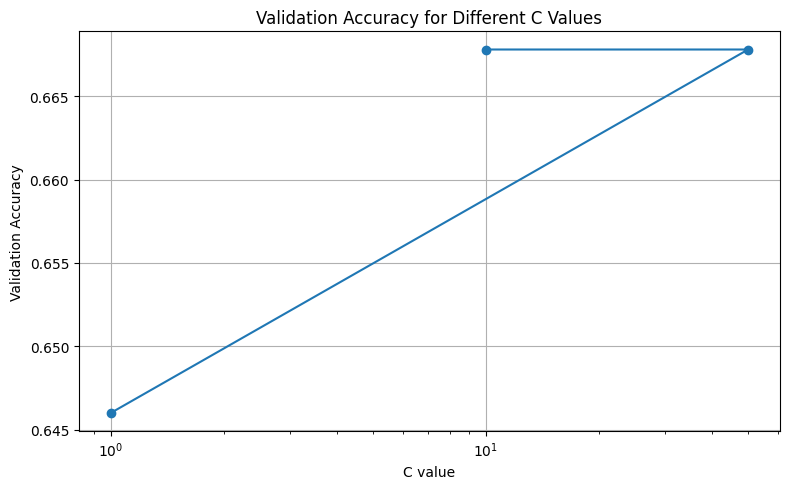

In [ ]:


plt.figure(figsize=(8, 5))

plt.plot(
    validation_results_df["C"],
    validation_results_df["validation_accuracy"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different C Values")
plt.grid(True)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "validation_accuracy_vs_C.png", dpi=300)
plt.show()

## Select best hyperparameter

In [ ]:


best_row = validation_results_df.iloc[0]

BEST_C = best_row["C"]
BEST_GAMMA = "scale"
BEST_VAL_ACC = best_row["validation_accuracy"]

print("Best model configuration:")
print("Model: RBF SVM")
print("Tuned hyperparameter: C")
print("Best C:", BEST_C)
print("Fixed gamma:", BEST_GAMMA)
print(f"Best validation accuracy: {BEST_VAL_ACC:.4f}")

Best model configuration:
Model: RBF SVM
Tuned hyperparameter: C
Best C: 10
Fixed gamma: scale
Best validation accuracy: 0.6678


## Train final model

In [ ]:


X_trainval_pca = np.vstack([X_train_pca, X_val_pca])
y_trainval = np.concatenate([y_train, y_val])

print("Train + Validation data:", X_trainval_pca.shape, y_trainval.shape)

final_model = SVC(
    kernel="rbf",
    C=BEST_C,
    gamma=BEST_GAMMA,
    decision_function_shape="ovr",
    random_state=RANDOM_STATE
)

start_time = time.time()

final_model.fit(X_trainval_pca, y_trainval)

final_training_time = time.time() - start_time

joblib.dump(final_model, RESULTS_DIR / "final_rbf_svm_model.pkl")

print(f"Final model trained in {final_training_time:.2f} seconds.")
print("Final model saved.")

Train + Validation data: (50000, 548) (50000,)
Final model trained in 2778.23 seconds.
Final model saved.


## Test evaluation

In [ ]:


test_pred = final_model.predict(X_test_pca)

test_accuracy = accuracy_score(y_test, test_pred)

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print()

report_text = classification_report(
    y_test,
    test_pred,
    target_names=CLASS_NAMES
)

print(report_text)

# Save classification report as text file
with open(RESULTS_DIR / "classification_report.txt", "w") as f:
    f.write(report_text)

Final Test Accuracy: 0.6552

              precision    recall  f1-score   support

    airplane       0.68      0.73      0.71      1000
  automobile       0.79      0.79      0.79      1000
        bird       0.56      0.53      0.54      1000
         cat       0.48      0.48      0.48      1000
        deer       0.58      0.62      0.60      1000
         dog       0.55      0.53      0.54      1000
        frog       0.72      0.75      0.74      1000
       horse       0.72      0.66      0.69      1000
        ship       0.72      0.73      0.73      1000
       truck       0.74      0.73      0.74      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.65     10000
weighted avg       0.66      0.66      0.65     10000



## Save classification report as CSV

In [ ]:


report_dict = classification_report(
    y_test,
    test_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

classification_report_df = pd.DataFrame(report_dict).transpose()

display(classification_report_df)

classification_report_df.to_csv(
    RESULTS_DIR / "classification_report.csv",
    index=True
)

,precision,recall,f1-score,support
airplane,0.684407,0.7330,0.707871,1000.0000
automobile,0.786495,0.7920,0.789238,1000.0000
bird,0.555556,0.5250,0.539846,1000.0000
cat,0.476331,0.4830,0.479643,1000.0000
deer,0.584121,0.6180,0.600583,1000.0000
dog,0.547718,0.5280,0.537678,1000.0000
frog,0.723077,0.7520,0.737255,1000.0000
horse,0.724289,0.6620,0.691745,1000.0000
ship,0.724551,0.7260,0.725275,1000.0000
truck,0.744162,0.7330,0.738539,1000.0000


## Confusion matrix

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,733,15,53,25,14,10,12,10,101,27
automobile,22,792,8,22,10,7,22,1,41,75
bird,67,9,525,75,113,80,62,33,26,10
cat,38,19,70,483,73,166,65,39,13,34
deer,23,10,83,56,618,50,61,69,21,9
dog,22,10,64,197,65,528,39,57,8,10
frog,12,15,47,45,66,36,752,7,11,9
horse,22,8,58,57,77,66,12,662,6,32
ship,96,57,26,17,10,6,7,9,726,46
truck,36,72,11,37,12,15,8,27,49,733


<Figure size 1200x1000 with 0 Axes>

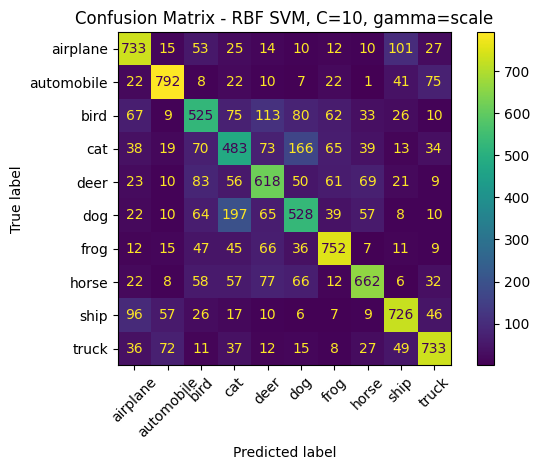

In [ ]:


cm = confusion_matrix(y_test, test_pred)

# Save confusion matrix as CSV
cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

display(cm_df)

cm_df.to_csv(RESULTS_DIR / "confusion_matrix.csv")

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title(f"Confusion Matrix - RBF SVM, C={BEST_C}, gamma={BEST_GAMMA}")
plt.tight_layout()

plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=300)
plt.show()

## Per-class accuracy

,class,accuracy
0,airplane,0.733
1,automobile,0.792
2,bird,0.525
3,cat,0.483
4,deer,0.618
5,dog,0.528
6,frog,0.752
7,horse,0.662
8,ship,0.726
9,truck,0.733


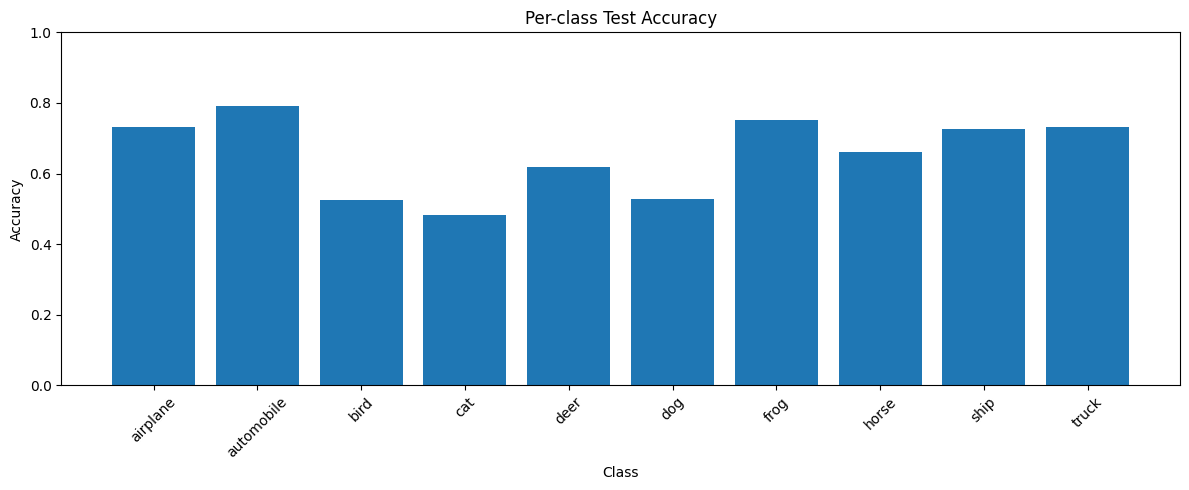

In [ ]:


per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "accuracy": per_class_accuracy
})

display(per_class_df)

per_class_df.to_csv(
    RESULTS_DIR / "per_class_accuracy.csv",
    index=False
)

plt.figure(figsize=(12, 5))

plt.bar(CLASS_NAMES, per_class_accuracy)

plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-class Test Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "per_class_accuracy.png", dpi=300)
plt.show()

## Save test predictions

In [ ]:


test_predictions_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": test_pred,
    "true_class": [CLASS_NAMES[i] for i in y_test],
    "predicted_class": [CLASS_NAMES[i] for i in test_pred],
    "correct": y_test == test_pred
})

display(test_predictions_df.head(10))

test_predictions_df.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False
)

,true_label,predicted_label,true_class,predicted_class,correct
0,3,6,cat,frog,False
1,8,8,ship,ship,True
2,8,1,ship,automobile,False
3,0,0,airplane,airplane,True
4,6,6,frog,frog,True
5,6,6,frog,frog,True
6,1,1,automobile,automobile,True
7,6,6,frog,frog,True
8,3,3,cat,cat,True
9,1,1,automobile,automobile,True


## Sample predictions

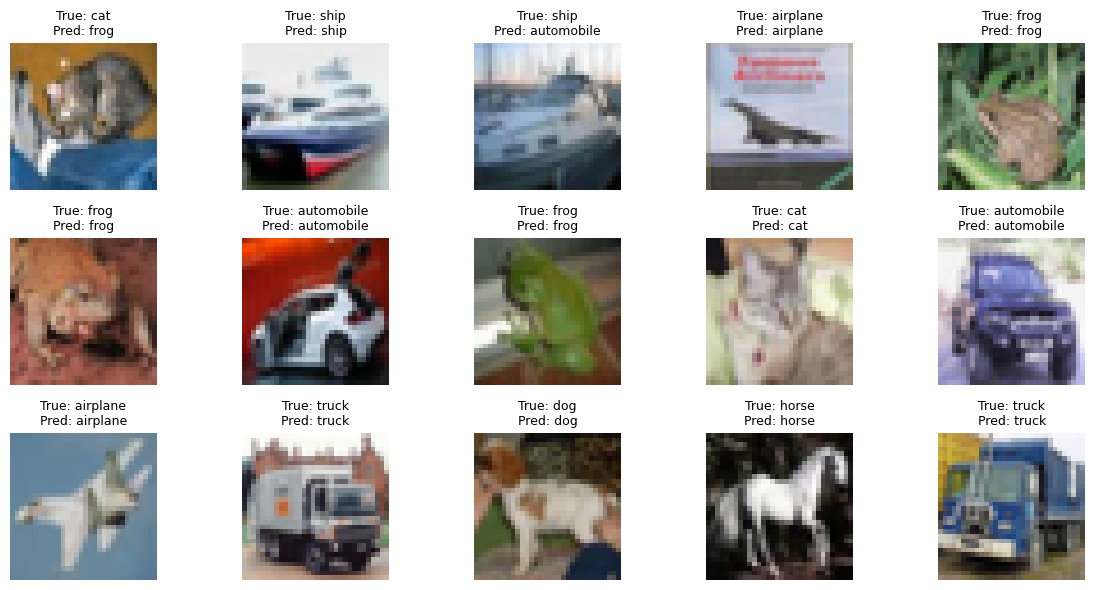

In [ ]:


plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i])

    true_name = CLASS_NAMES[y_test[i]]
    pred_name = CLASS_NAMES[test_pred[i]]

    plt.title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
    plt.axis("off")

plt.tight_layout()

plt.savefig(RESULTS_DIR / "sample_predictions.png", dpi=300)
plt.show()

## Final summary

In [ ]:


final_summary = pd.DataFrame([{
    "task": "Task 2 Machine Learning",
    "learning_type": "Supervised multi-class classification",
    "dataset": "CIFAR-10",
    "train_size": len(X_train),
    "validation_size": len(X_val),
    "test_size": len(X_test),
    "feature_method": "HOG + HSV Colour Histogram + LBP",
    "model": "RBF Kernel Support Vector Machine",
    "tuned_hyperparameter": "C",
    "best_C": BEST_C,
    "fixed_gamma": BEST_GAMMA,
    "validation_accuracy": BEST_VAL_ACC,
    "test_accuracy": test_accuracy,
    "final_training_time_sec": final_training_time,
    "pca_components": X_train_pca.shape[1]
}])

display(final_summary)

final_summary.to_csv(
    RESULTS_DIR / "final_summary.csv",
    index=False
)

print("All useful results saved in:", RESULTS_DIR)

,task,learning_type,dataset,train_size,validation_size,test_size,feature_method,model,tuned_hyperparameter,best_C,fixed_gamma,validation_accuracy,test_accuracy,final_training_time_sec,pca_components
0,Task 2 Machine Learning,Supervised multi-class classification,CIFAR-10,45000,5000,10000,HOG + HSV Colour Histogram + LBP,RBF Kernel Support Vector Machine,C,10,scale,0.6678,0.6552,2778.233328,548


All useful results saved in: Machine_learning_result


## Report explanation
###Task 2 Machine Learning Summary:

The CIFAR-10 image classification problem was formulated as a supervised multi-class classification task.
The dataset contains 10 image classes, including airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

The same data partitioning was used:
- Training data: 45,000 images
- Validation data: 5,000 images
- Test data: 10,000 images

Feature Engineering:
A combined image feature extraction method was used:
1. HOG features were used to capture shape and edge information.
2. HSV colour histogram was used to capture colour information.
3. LBP features were used to capture texture patterns.

Dimensionality Reduction:
PCA was applied to reduce feature dimensionality while keeping 95% of the variance.
This helped reduce training time and remove redundant information.

Machine Learning Model:
An RBF Kernel Support Vector Machine was selected because it can learn non-linear decision boundaries.
This is useful for CIFAR-10 because image classes are not easily separated using simple linear patterns.

Hyperparameter Tuning:
Only one hyperparameter was tuned: C.
Gamma was fixed as 'scale'.
The C parameter controls the regularisation strength of the SVM model.
Different C values were tested using the validation set, and the best C value was selected.

Evaluation:
The final model was trained using the combined training and validation data.
It was evaluated on the test set using:
- Test accuracy
- Classification report
- Confusion matrix
- Per-class accuracy
- Sample predictions